## Support Vector Regressor Implimentation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
## lets create synthetic  data points
from sklearn.datasets import make_regression

In [4]:
X,y  = make_regression(n_samples=1000,n_features=2,n_targets=1,noise=3.0)

In [5]:
X

array([[-0.3499981 , -0.48406897],
       [ 0.68382881, -0.74461013],
       [ 1.06146072, -0.94637817],
       ...,
       [ 0.68800494, -1.00755639],
       [-0.68681365,  0.47384091],
       [-0.56525796, -2.0982861 ]])

In [6]:
y

array([-3.70645045e+01, -4.05797797e+00,  3.32387512e+00, -5.38820121e+01,
       -4.19273550e+01,  1.01231390e+00,  5.09214114e+01, -1.09230359e+01,
       -5.06239165e+01, -1.78440043e+01, -2.38858886e+01, -1.23561997e+01,
       -4.24817532e+01,  1.04212624e+01,  2.38527482e+01,  3.50470748e+01,
        5.16040063e+01, -3.90623864e+01,  4.21119898e+01, -7.93063292e+01,
       -2.18280930e+01, -5.18413490e+01, -9.90077718e+00,  3.86987642e+01,
        8.25942627e+00,  3.83451627e+01,  1.77034503e+01,  3.59189348e+01,
       -3.35193928e+01,  7.97955585e+01,  7.84002441e+01,  5.49393714e+00,
        3.63419144e+01, -1.81791955e+01,  9.50800378e+00,  1.85777327e+01,
       -3.47423159e+01,  1.51326271e+01, -7.63811135e+01,  5.91453182e+01,
        5.51902079e+01, -7.27851978e+01,  2.00217525e+01, -4.09029441e+01,
        7.40972835e+00,  1.17656423e+00,  1.20904150e+02, -3.20314171e+01,
        4.28991817e+01, -1.25055425e+02,  3.44223118e+01, -1.36495051e+02,
        6.18995461e+01, -

In [7]:
pd.DataFrame(X)[0]

0     -0.349998
1      0.683829
2      1.061461
3     -1.458625
4     -1.537214
         ...   
995    0.166974
996   -0.630234
997    0.688005
998   -0.686814
999   -0.565258
Name: 0, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

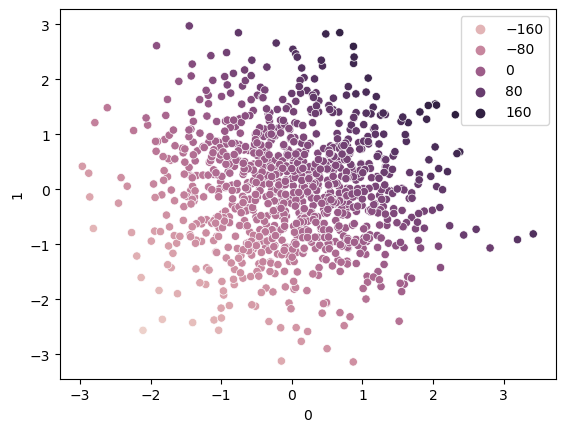

In [8]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [15]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [16]:
from sklearn.svm import SVR

In [17]:
svr = SVR(kernel='linear')

In [18]:
svr.fit(X_train,y_train)

SVR(kernel='linear')

In [19]:
svr.coef_

array([[44.92768782, 44.08751428]])

In [20]:
## prediction
y_pred = svr.predict(X_test)

In [21]:
y_pred

array([ 1.46243323e+02, -2.31582113e+01, -6.62627022e+01, -4.34070525e+01,
       -2.12360954e+01, -7.89204951e+00,  1.00757992e+02, -4.87690878e+01,
       -1.65596386e+01, -2.45954046e+01, -1.60951616e+01, -4.28166024e+01,
        1.41107501e+01, -7.41561342e+00, -2.77982435e+01, -4.00864433e+01,
        3.95161560e+01, -1.01952251e+02, -5.07608156e+01, -1.48567233e+01,
       -7.54444211e+01, -1.78026768e+01,  8.30831754e+01, -7.81877989e+01,
        7.99751112e+01,  4.83355828e+01,  3.91308694e+01,  4.02502759e+01,
       -4.10604510e+01, -6.49902012e+01, -8.35447185e+01,  1.15989028e+02,
        2.85566117e+01,  1.97452355e+01,  5.57410585e+01,  6.97165908e+01,
       -6.00854445e+01,  6.44243266e+01,  1.34307679e+01, -5.83485801e+01,
        3.37268044e+01, -1.04358353e+02, -7.91384097e+01,  1.18348132e+02,
       -8.20593695e+01,  1.69128313e+01, -4.61396243e+01, -5.55040553e+01,
        4.18427530e+01,  6.94686796e+01,  3.75893548e+01,  1.17323123e+02,
        3.12877074e+01,  

In [22]:
from sklearn.metrics import r2_score

In [23]:
print(r2_score(y_test,y_pred))

0.9977365103928165


## Hyperparametere Tuning With SVC

In [24]:
from sklearn.model_selection import GridSearchCV


In [26]:
# defining parameter range 
param_grid = {'c':[0,1,1,10,100,1000],
             'gamma':[1,0.1,0.01,0.001,0.0001],
             'kernel':['linear'],
              'epsilon':[0.1,0.2,0.3]
             }

In [29]:
grid =GridSearchCV(SVR(),param_grid=param_grid,refit = True,cv=5,verbose=3)

In [30]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


ValueError: Invalid parameter 'c' for estimator SVR(). Valid parameters are: ['C', 'cache_size', 'coef0', 'degree', 'epsilon', 'gamma', 'kernel', 'max_iter', 'shrinking', 'tol', 'verbose'].